# LLM-Based Feature Selection for ICU Delirium — Analysis

`2. feature selection experiment` 가 만든 `results/` 를 **읽기만 해서** 논문의 표·그림을 재생성한다.
API 를 호출하지 않으므로 키가 필요 없고, 위에서 아래로 한 번에 실행된다.

| 절 | 내용 | 산출물 |
|---|---|---|
| §0 | 경로 · 모델 레지스트리 · 공통 유틸 | — |
| §1 | Feature pool — 규칙 1·2 적합성 검증 (107개) | `pool_audit.csv` |
| §2 | 실행 결과 인벤토리 · 무결성 검사 | `inventory.csv` |
| §3 | seed별 JSONL → 평균 순위 벡터 | — |
| §4 | Table 1 — seed 간 일관성 | `Table1_seed_consistency.csv` |
| §5 | Figure 2 — 평균 순위 분포 | `Figure2_rank_distribution.png` |
| §6 | Table 2 · 3 — 방법 · 모델 간 순위 상관 | `Table2_*.csv`, `Table3_*.csv` |
| §7 | Table 4 · Figure 3 — LMprior | `Table4_lmprior.csv`, `Figure3_*.png` |
| §8 | 종합 — 상위 feature · 토큰 사용량 | `top30_*.csv`, `token_usage_summary.csv` |

---

### 실험 구성

- **Feature pool** : 107개 (선행연구 11편에서 추출, 규칙 1·2로 정리 — §1 참조)
- **방법** : LLM-Rank, LLM-Score, LLM-Seq, LMprior
- **모델** : GPT-4.1, Gemini 2.5 Pro, Claude Sonnet 4.5
- **seed** : 42–46 (5회 반복), `temperature = 0`

LMprior 는 첫 토큰의 `top_logprobs` 에서 `log P(Y) − log P(N)` 을 읽는 방법이므로
**토큰 로그확률을 노출하는 모델에서만** 정의된다. 세 벤더 중 이 조건을 만족하는 것은
GPT-4.1 뿐이라 LMprior 는 GPT 단독으로 수행했다.


## §0. 경로 · 모델 레지스트리 · 공통 유틸

In [1]:
# =============================================================================
# 0-1. 설정 — 대부분의 변경은 이 셀 하나만 고치면 된다.
# =============================================================================
import os, re, json, itertools, unicodedata
import numpy as np
import pandas as pd

# ---- 경로 자동 탐색 ----------------------------------------------------------
_MARKERS = ('1. feature pool generator', '2. feature selection experiment')

def find_root(start=None, max_up=6):
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(max_up):
        if all(os.path.isdir(os.path.join(cur, m)) for m in _MARKERS):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError("프로젝트 루트를 찾지 못했습니다. ROOT 를 직접 지정하세요.")

ROOT = find_root()
DIR1 = os.path.join(ROOT, '1. feature pool generator')
DIR2 = os.path.join(ROOT, '2. feature selection experiment')
DIR3 = os.path.join(ROOT, '3. analyze feature selection method')

RESULTS = os.path.join(DIR2, 'results')          # results/{method}/{model}/seed{n}.jsonl
AGG_DIR = os.path.join(RESULTS, 'aggregate')     # 실험 노트북이 만든 집계 CSV
OUT     = os.path.join(DIR3, 'outputs')          # 이 노트북의 산출물
os.makedirs(OUT, exist_ok=True)

POOL_FILE    = os.path.join(DIR1, 'feature_pool.txt')
MAPPING_FILE = os.path.join(DIR1, 'variable_mapping.txt')
MATRIX_FILE  = os.path.join(DIR1, 'paper_feature_matrix.txt')
EXCL_FILE    = os.path.join(DIR1, 'excluded_features.txt')

SEEDS = [42, 43, 44, 45, 46]

# ---- 모델 레지스트리 ---------------------------------------------------------
MODELS = {
    'gpt':    dict(vendor='OpenAI',    model='gpt-4.1-2025-04-14',
                   label='GPT-4.1 (OpenAI)',              short='GPT-4.1'),
    'gemini': dict(vendor='Google',    model='gemini-2.5-pro',
                   label='Gemini 2.5 Pro (Google)',       short='Gemini 2.5 Pro'),
    'claude': dict(vendor='Anthropic', model='claude-sonnet-4-5-20250929',
                   label='Claude Sonnet 4.5 (Anthropic)', short='Claude Sonnet 4.5'),
}
MODEL_ORDER   = ['gpt', 'gemini', 'claude']
MODEL_SHORT   = {k: v['short'] for k, v in MODELS.items()}
LMPRIOR_MODEL = 'gpt'                    # logprobs 를 노출하는 유일한 모델

METHODS  = ['score', 'rank', 'seq']
METHNAME = {'score': 'Scoring', 'rank': 'Ranking', 'seq': 'Sequencing',
            'lmprior': 'LMprior'}

# 각 방법의 JSONL 에서 순위/점수를 담고 있는 필드
VALUE_FIELD = {'rank': 'rank', 'seq': 'step', 'score': 'score', 'lmprior': 'score'}
# 값이 클수록 중요한 방법 (점수 계열) — 순위로 바꿀 때 내림차순 정렬한다
HIGHER_IS_BETTER = {'score', 'lmprior'}

# ---- 통계 파라미터 (논문과 동일하게 고정) ------------------------------------
B         = 5000
BOOT_SEED = 20260804

print('ROOT ->', ROOT)
for name, p in [('DIR1', DIR1), ('DIR2', DIR2), ('results', RESULTS), ('aggregate', AGG_DIR)]:
    print(f'  {"OK " if os.path.isdir(p) else "!! "} {name:10} {p}')
print('OUT  ->', OUT)

ROOT -> c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출
  OK  DIR1       c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출\1. feature pool generator
  OK  DIR2       c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출\2. feature selection experiment
  OK  results    c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출\2. feature selection experiment\results
  OK  aggregate  c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출\2. feature selection experiment\results\aggregate
OUT  -> c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출\3. analyze feature selection method\outputs


In [2]:
# =============================================================================
# 0-2. 공통 유틸
# =============================================================================

def read_jsonl(path):
    """JSONL 리더.

    레코드 구분자는 '\n' 뿐이다. str.splitlines() 를 쓰면 안 된다 — U+2028 / U+2029 /
    U+0085 에서도 끊어지는데, 이 문자들은 JSON 문자열 안에서 합법이며 실제로 OpenAI
    logprob 토큰 값에 등장한다. splitlines() 는 그런 레코드를 파싱 불가능한 조각으로
    쪼개 버린다.
    """
    with open(path, encoding='utf-8') as f:
        text = f.read()
    rows, bad = [], []
    for i, line in enumerate(text.split('\n'), 1):
        if not line.strip():
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as e:
            bad.append((i, str(e)[:60]))
    if bad:
        print(f'  [warn] {os.path.basename(path)}: {len(bad)}개 줄 파싱 실패 (첫 줄 {bad[0][0]})')
    return rows


def read_tsv(path):
    """폴더 1이 내보낸 탭 구분 txt 로더. CR·BOM·앞뒤 공백을 털어낸다."""
    df = pd.read_csv(path, sep='\t', encoding='utf-8-sig', dtype=str, keep_default_na=False)
    df.columns = [str(c).strip().strip('﻿') for c in df.columns]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip()
    return df


def load_pool(path=POOL_FILE):
    with open(path, encoding='utf-8-sig') as f:
        return [l.strip() for l in f if l.strip()]


POOL     = load_pool()
POOL_SET = set(POOL)
N_POOL   = len(POOL)
_CANON   = {p.lower(): p for p in POOL}

def canon(name):
    """대소문자만 다른 표기를 pool 표기로 되돌린다."""
    return _CANON.get(str(name).strip().lower(), str(name).strip())


def jsonl_path(method, model_key, seed):
    return os.path.join(RESULTS, method, model_key, f'seed{seed}.jsonl')

def agg_csv_path(method, model_key):
    return os.path.join(AGG_DIR, f'{method}_{model_key}.csv')


print(f'feature pool : {N_POOL} features')
print('  예시 :', ', '.join(POOL[:3]), '...')

feature pool : 107 features
  예시 : Acute Kidney Injury, Acute Myocardial Infarction, Acute Physiology and Chronic Health Evaluation (APACHE) Score ...


## §1. Feature pool — 규칙 1·2 적합성 검증

선행연구 11편에서 추출한 원본 변수 라벨을 **두 규칙만으로** 정리해 107개 pool 을 만들었다.
사람의 개별 판단이 끼어들 여지를 없애기 위해 규칙은 두 개로 제한했고, 변수별 예외는 두지 않았다.

**규칙 1 (동일성).** 같은 것을 가리키는 라벨은 하나로 병합한다. 병합 근거는 둘 중 하나뿐이다 —
① 동의어·약어 관계이거나, ② 동일한 DB 필드에서 나오거나. *파생 관계는 병합 근거가 아니다.*
예컨대 BMI 는 키·몸무게에서 계산되지만 서로 다른 변수이므로 병합하지 않는다.

**규칙 2 (확정성).** ICU 입실 후 24시간 이내에, **환자 한 명의 자료만으로** 값이 확정되지
않는 변수는 제외한다. 재원기간처럼 시점상 미확정인 것(시점 위반)과, 코호트 전체를 적합해야
정해지는 잠재계층 같은 것(독립성 위반)이 여기 걸린다.

**적용하지 않은 것.** 보고 빈도, 결측률, 예상 중요도, 변수 간 중복성은 기준으로 쓰지 않았다.
특히 중복성을 배제 사유로 삼지 않은 것은 의도적이다 — 선행연구 어느 편도 중복을 정리하지
않으며(예: Mei 2024 는 CCI 와 그 구성요소를 나란히 싣는다), 트리 기반 모델에서는 상관된
변수가 성능을 떨어뜨리지 않는다.

아래 셀은 폴더 1의 세 산출물이 서로 모순이 없는지, 그리고 제외된 라벨이 모두 규칙 2(또는
범위 밖)로 설명되는지를 기계적으로 확인한다.

In [3]:
# =============================================================================
# 1-1. pool · mapping · matrix 3자 대조
# =============================================================================
mapping = read_tsv(MAPPING_FILE)
matrix  = read_tsv(MATRIX_FILE)

map_names = [s for s in mapping.iloc[:, 0] if s]
mat_names = [s for s in matrix.iloc[:, 0]  if s]

print(f'feature_pool.txt         : {len(POOL)}')
print(f'variable_mapping.txt     : {len(map_names)}')
print(f'paper_feature_matrix.txt : {len(mat_names)}')

_p, _m, _x = set(POOL), set(map_names), set(mat_names)
if _p != _m:
    print('\n[pool vs mapping] pool에만:', sorted(_p - _m), '| mapping에만:', sorted(_m - _p))
if _p != _x:
    print('[pool vs matrix ] pool에만:', sorted(_p - _x), '| matrix에만:', sorted(_x - _p))

assert _p == _m, 'feature_pool.txt 와 variable_mapping.txt 가 다릅니다 — 폴더 1을 다시 실행하세요.'
assert _p == _x, 'feature_pool.txt 와 paper_feature_matrix.txt 가 다릅니다.'
assert len(POOL) == len(set(POOL)), 'feature_pool.txt 에 중복이 있습니다.'

paper_cols = [c for c in matrix.columns[1:] if c.lower() != 'paper count']
n_variants = int(pd.to_numeric(mapping.iloc[:, 2], errors='coerce').fillna(0).sum())
print(f'\nOK — 세 파일 모두 동일한 {N_POOL}개 feature')
print(f'선행연구 {len(paper_cols)}편 · 원본 라벨 {n_variants}개 -> 규칙 1로 {N_POOL}개에 병합')

feature_pool.txt         : 107
variable_mapping.txt     : 107
paper_feature_matrix.txt : 107

OK — 세 파일 모두 동일한 107개 feature
선행연구 11편 · 원본 라벨 215개 -> 규칙 1로 107개에 병합


In [4]:
# =============================================================================
# 1-2. 규칙 1 — 병합 현황
# =============================================================================
mapping['n_variants'] = pd.to_numeric(mapping.iloc[:, 2], errors='coerce').fillna(0).astype(int)
merged = mapping[mapping.n_variants > 1]
print(f'규칙 1로 병합된 feature : {len(merged)} / {N_POOL} '
      f'(원본 라벨 {int(merged.n_variants.sum())}개가 흡수됨)')
print(f'단일 라벨 그대로인 feature : {int((mapping.n_variants == 1).sum())}')

print('\n병합 폭이 큰 상위 8개:')
display(merged.nlargest(8, 'n_variants')[[mapping.columns[0], mapping.columns[1], 'n_variants']]
              .rename(columns={mapping.columns[0]: 'Unified Feature',
                               mapping.columns[1]: 'Original Labels'})
              .reset_index(drop=True))

규칙 1로 병합된 feature : 50 / 107 (원본 라벨 158개가 흡수됨)
단일 라벨 그대로인 feature : 57

병합 폭이 큰 상위 8개:


,Unified Feature,Original Labels,n_variants
0,White Blood Cell Count,WBC | WBC (White Blood Cell) | WBC (White Bloo...,9
1,Renal Disease,CKD (Chronic Kidney Disease) | Chronic kidney ...,6
2,Acute Physiology and Chronic Health Evaluation...,APACHE II score | APS III (Acute Physiology Sc...,5
3,Creatinine,Blood creatinine | Creatinine | Creatinine (Cr...,5
4,Oxygen Saturation,Oxygen saturation (SpO2) | Oxygen saturation (...,5
5,Partial Thromboplastin Time,Activated partial thromboplastin time (aPTT) |...,5
6,Arterial Partial Pressure Of Carbon Dioxide,PCO2 (Partial pressure of carbon dioxide) | PC...,4
7,Arterial Partial Pressure Of Oxygen,PO2 (Partial pressure of oxygen) | PO₂ | Parti...,4


In [5]:
# =============================================================================
# 1-3. 규칙 2 — 제외 변수. 사유는 폴더 1이 단일 소스이며 여기서 하드코딩하지 않는다.
# =============================================================================
excluded = read_tsv(EXCL_FILE)
excluded.columns = ['label', 'reason'][:len(excluded.columns)]
print(f'제외된 원본 라벨 : {len(excluded)}개')

# 모든 제외 사유가 규칙 2 또는 '범위 밖' 으로 설명되는지 확인
tag = excluded.reason.str.extract(r'\[([^\]]+)\]')[0].fillna('(no tag)')
display(tag.value_counts().rename('n').to_frame())
unknown = excluded[~tag.isin(['Rule 2', 'Out of scope'])]
assert len(unknown) == 0, f'[Rule 1]/[Rule 2] 로 설명되지 않는 제외가 있습니다:\n{unknown}'
print('OK — 모든 제외가 [Rule 2] 또는 [Out of scope] 로 설명됩니다. 규칙 1은 병합만 하고 제외하지 않습니다.')
display(excluded)

pool_audit = mapping[[mapping.columns[0], mapping.columns[1], 'n_variants']].copy()
pool_audit.columns = ['feature', 'original_labels', 'n_variants']
pool_audit.to_csv(os.path.join(OUT, 'pool_audit.csv'), index=False, encoding='utf-8-sig')

제외된 원본 라벨 : 7개


,n
0,
규칙 2,6
범위 밖,1


OK — 모든 제외가 규칙 2 또는 범위 밖으로 설명됩니다. 규칙 1은 병합만 하고 제외하지 않습니다.


,label,reason
0,Hospital length of stay,[규칙 2] 시점 위반 — 위와 동일
1,ICU length of stay,[규칙 2] 시점 위반 — 24시간 시점에 미확정이며 섬망의 결과로 늘어남
2,ICU length of stay (days),[규칙 2] 시점 위반 — 24시간 시점에 미확정이며 섬망의 결과로 늘어남
3,MBG trajectory (latent growth mixture modeling...,[규칙 2] 독립성 위반 — LGMM 잠재계층은 코호트 적합 결과에 의존하므로 환자...
4,Others,[범위 밖] 원 논문의 '기타' 칸. 임상 변수가 아닌 추출 아티팩트
5,Total length of stay in ICU (ICU LOS),[규칙 2] 시점 위반 — 24시간 시점에 미확정이며 섬망의 결과로 늘어남
6,Ventilator service time in ICU (days),[규칙 2] 시점 위반 — 인공호흡 적용 기간은 24시간 시점에 미확정이며 섬망의 ...


## §2. 실행 결과 인벤토리 · 무결성 검사

`results/` 의 모든 JSONL 에 대해 아래를 확인한다. 하나라도 어긋나면 그 파일은 `CHECK` 로
표시되고 §3 이후 분석에서 제외된다.

- 레코드 수가 pool 크기(107)와 같은가
- feature 집합이 pool 과 정확히 일치하는가 (누락 · 중복 · pool 밖 이름 탐지)
- 순위 계열(`rank`, `seq`)에서 순위가 1..107 연속인가
- `model` 필드가 레지스트리의 스냅샷 ID 와 일치하는가

In [6]:
# =============================================================================
# 2-1. 전수 검사
# =============================================================================
ALL_METHODS = METHODS + ['lmprior']

def inspect(method, model_key, seed):
    p = jsonl_path(method, model_key, seed)
    if not os.path.exists(p):
        return dict(status='MISSING', n=0, note='파일 없음')
    rows = read_jsonl(p)
    if not rows:
        return dict(status='EMPTY', n=0, note='레코드 0개')

    feats = [r.get('feature') for r in rows]
    notes = []
    if len(rows) != N_POOL:
        notes.append(f'레코드 {len(rows)} != {N_POOL}')
    if len(feats) != len(set(feats)):
        notes.append('feature 중복')
    miss, extra = POOL_SET - set(feats), set(feats) - POOL_SET
    if miss:
        notes.append(f'누락 {len(miss)}: {sorted(miss)[:3]}')
    if extra:
        notes.append(f'pool 밖 {len(extra)}: {sorted(extra)[:3]}')

    fld = VALUE_FIELD[method]
    if fld not in rows[0]:
        notes.append(f"'{fld}' 필드 없음")
    elif method in ('rank', 'seq'):
        if sorted(int(r[fld]) for r in rows) != list(range(1, len(rows) + 1)):
            notes.append(f'{fld} 이 1..{len(rows)} 연속이 아님')

    snaps = {r.get('model') for r in rows} - {None}
    exp = MODELS[model_key]['model']
    if snaps and snaps != {exp}:
        notes.append(f'스냅샷 {sorted(snaps)} != {exp}')

    return dict(status='OK' if not notes else 'CHECK', n=len(rows), note=' / '.join(notes))


inv_rows, AVAILABLE = [], {}
for me in ALL_METHODS:
    for mk in MODEL_ORDER:
        if me == 'lmprior' and mk != LMPRIOR_MODEL:
            continue
        ok = []
        for s in SEEDS:
            info = inspect(me, mk, s)
            inv_rows.append(dict(method=me, model=mk, seed=s, **info))
            if info['status'] == 'OK':
                ok.append(s)
        AVAILABLE[(me, mk)] = ok

inventory = pd.DataFrame(inv_rows)
inventory.to_csv(os.path.join(OUT, 'inventory.csv'), index=False, encoding='utf-8-sig')

COMPLETE = {k: v for k, v in AVAILABLE.items() if len(v) == len(SEEDS)}
summary = (inventory.assign(ok=lambda d: d.status.eq('OK').astype(int))
                    .pivot_table(index='model', columns='method', values='ok',
                                 aggfunc='sum', fill_value=0)
                    .reindex(index=MODEL_ORDER, columns=ALL_METHODS, fill_value=0))
print(f'정상 seed 수 / {len(SEEDS)}')
display(summary)

bad = inventory[~inventory.status.eq('OK')]
if len(bad):
    print('확인이 필요한 파일:')
    display(bad[['method', 'model', 'seed', 'n', 'note']])
else:
    print(f'OK — {len(inventory)}개 파일 전부 정상 '
          f'({len(inventory) * N_POOL:,} 레코드)')

ANALYSIS_MODELS  = [mk for mk in MODEL_ORDER if any((me, mk) in COMPLETE for me in METHODS)]
ANALYSIS_METHODS = [me for me in METHODS if any((me, mk) in COMPLETE for mk in ANALYSIS_MODELS)]
HAS_LMPRIOR      = ('lmprior', LMPRIOR_MODEL) in COMPLETE
print('\n분석 대상 :', [MODEL_SHORT[m] for m in ANALYSIS_MODELS],
      '×', [METHNAME[m] for m in ANALYSIS_METHODS],
      '| LMprior', 'O' if HAS_LMPRIOR else 'X')

정상 seed 수 / 5


method,score,rank,seq,lmprior
model,,,,
gpt,5,5,5,5
gemini,5,5,5,0
claude,5,5,5,0


OK — 50개 파일 전부 정상 (5,350 레코드)

분석 대상 : ['GPT-4.1', 'Gemini 2.5 Pro', 'Claude Sonnet 4.5'] × ['Scoring', 'Ranking', 'Sequencing'] | LMprior O


## §3. 집계 — seed별 JSONL → 평균 순위 벡터

집계 규칙은 실험 노트북의 `results/aggregate/*.csv` 와 동일하게 맞췄다.

- `score` : seed별 **점수를 먼저 평균**낸 뒤 내림차순 rank
- `rank` / `seq` / `lmprior` : seed마다 순위를 구한 뒤 **순위를 평균**

LMprior 를 `score` 처럼 "점수 평균 → rank" 로 집계하면 결과가 달라진다. LMprior 점수는
`log P(Y) − log P(N)` 이라 스케일이 seed마다 크게 흔들려서, 평균을 먼저 내면 한 seed의
극단값이 순위를 끌고 간다(두 방식은 최대 17.4 순위까지 어긋난다). 논문 수치는 순위 평균이다.

`VERIFY_AGG = True` 면 기존 집계 CSV와 대조해 최대 차이를 출력한다. **0이어야 정상.**

In [7]:
# =============================================================================
# 3-1. 집계기
# =============================================================================
VERIFY_AGG = True

def per_seed_long(method, model_key, seeds=None):
    """-> DataFrame[feature, seed, rank]"""
    seeds = seeds or AVAILABLE.get((method, model_key), [])
    fld   = VALUE_FIELD[method]
    rows  = []
    for s in seeds:
        df = pd.DataFrame(read_jsonl(jsonl_path(method, model_key, s)))
        if method in HIGHER_IS_BETTER:
            r = df[fld].astype(float).round(6).rank(method='min', ascending=False)
        else:
            r = df[fld].astype(float)
        for f, v in zip(df['feature'], r):
            rows.append({'feature': canon(f), 'seed': s, 'rank': round(float(v), 6)})
    return pd.DataFrame(rows)


def avg_vec(method, model_key, seeds=None):
    """-> DataFrame[feature, v]   v = 평균 순위 (작을수록 중요)"""
    seeds = seeds or AVAILABLE.get((method, model_key), [])
    if not seeds:
        raise KeyError(f'{method}/{model_key}: 사용 가능한 seed 없음')

    if method == 'score':                      # 점수 평균 -> rank
        merged = None
        for s in seeds:
            d = pd.DataFrame(read_jsonl(jsonl_path(method, model_key, s)))
            d['feature'] = d['feature'].map(canon)
            d = d[['feature', 'score']].rename(columns={'score': f'sc_{s}'})
            merged = d if merged is None else merged.merge(d, on='feature')
        merged['avg_score'] = merged[[f'sc_{s}' for s in seeds]].astype(float).mean(axis=1)
        # 동점이 많은 지표(0.95, 0.914 …)라 부동소수점 잔차 1e-16 이 동점을 갈라
        # 순위를 최대 2 어긋나게 만든다. 순위를 매기기 전에 반드시 반올림한다.
        merged['v'] = merged['avg_score'].round(6).rank(ascending=False, method='min')
        return merged[['feature', 'v']].sort_values('v').reset_index(drop=True)

    long = per_seed_long(method, model_key, seeds)      # 순위 평균
    out = long.pivot(index='feature', columns='seed', values='rank').mean(axis=1).reset_index()
    out.columns = ['feature', 'v']
    return out.sort_values('v').reset_index(drop=True)

print('aggregators ready')

aggregators ready


In [8]:
# =============================================================================
# 3-2. results/aggregate/*.csv 와 대조 (Δ = 0 이어야 정상)
# =============================================================================
def load_agg_csv(method, model_key):
    df = pd.read_csv(agg_csv_path(method, model_key), encoding='utf-8-sig')
    df.columns = [c.strip().lower().lstrip('﻿') for c in df.columns]
    fc = next(c for c in df.columns if 'feature' in c)
    df[fc] = df[fc].map(canon)
    if 'avg_rank' in df.columns:                 # rank, lmprior
        df['v'] = df['avg_rank'].astype(float)
    elif 'avg_step' in df.columns:               # seq — step 이 곧 순위
        df['v'] = df['avg_step'].astype(float)
    else:                                        # score — 점수를 순위로
        sc = next(c for c in df.columns if 'score' in c)
        df['v'] = df[sc].astype(float).round(6).rank(ascending=False, method='min')
    return df[[fc, 'v']].rename(columns={fc: 'feature'})


if VERIFY_AGG:
    print(f'{"method":9} {"model":8} {"n":>4}  max|Δ rank|')
    print('-' * 42)
    for me, mk in sorted(COMPLETE):
        if not os.path.exists(agg_csv_path(me, mk)):
            print(f'{me:9} {mk:8}   --  집계 CSV 없음'); continue
        m = avg_vec(me, mk).merge(load_agg_csv(me, mk), on='feature', suffixes=('_raw', '_csv'))
        d = float((m['v_raw'] - m['v_csv']).abs().max())
        print(f'{me:9} {mk:8} {len(m):>4}  {d:.6f}  {"OK" if d == 0 else "<-- 확인 필요"}')

method    model       n  max|Δ rank|
------------------------------------------
lmprior   gpt       107  0.000000  OK
rank      claude    107  0.000000  OK
rank      gemini    107  0.000000  OK
rank      gpt       107  0.000000  OK
score     claude    107  0.000000  OK
score     gemini    107  0.000000  OK
score     gpt       107  0.000000  OK
seq       claude    107  0.000000  OK
seq       gemini    107  0.000000  OK
seq       gpt       107  0.000000  OK


In [9]:
# =============================================================================
# 3-3. 분석용 벡터 V[(방법, 모델)] — JSONL 원본에서 직접 계산
# =============================================================================
V = {}
for me, mk in sorted(COMPLETE):
    if me == 'lmprior':
        continue                                   # §7에서 따로
    V[(METHNAME[me], mk)] = avg_vec(me, mk)

for (me, mk), v in V.items():
    assert set(v['feature']) == POOL_SET, f'{me}/{mk}: pool 불일치'
    assert len(v) == N_POOL

print(f'{len(V)}개 벡터 로드')
for me in [METHNAME[m] for m in ANALYSIS_METHODS]:
    print(f'  {me:11}', ' · '.join(MODEL_SHORT[mk] for (m, mk) in sorted(V) if m == me))

9개 벡터 로드
  Scoring     Claude Sonnet 4.5 · Gemini 2.5 Pro · GPT-4.1
  Ranking     Claude Sonnet 4.5 · Gemini 2.5 Pro · GPT-4.1
  Sequencing  Claude Sonnet 4.5 · Gemini 2.5 Pro · GPT-4.1


## §4. Table 1 — seed 간 일관성

seed마다 순위 벡터를 얻어 feature별 표준편차(ddof=1)를 구하고, 그중 **변동이 큰 상위 30개**의
평균을 낸다. 값이 작을수록 같은 방법·모델이 seed를 바꿔도 비슷한 답을 낸다는 뜻이다.
`temperature = 0` 이므로 이론상 0이어야 하지만, 벤더 측 비결정성 때문에 0이 아닐 수 있다.

In [10]:
def top30_std_mean(long_df, topn=30):
    piv = long_df.pivot(index='feature', columns='seed', values='rank')
    std = piv.std(axis=1)                                       # ddof=1
    std = std.apply(lambda x: 0.0 if np.isclose(x, 0, atol=1e-8) else x)
    return float(std.sort_values(ascending=False).head(topn).mean())


rows = []
for mk in ANALYSIS_MODELS:
    row = {'Model': MODELS[mk]['label']}
    for me in ANALYSIS_METHODS:
        row[METHNAME[me]] = (round(top30_std_mean(per_seed_long(me, mk)), 4)
                             if (me, mk) in COMPLETE else np.nan)
    rows.append(row)
table1 = pd.DataFrame(rows).set_index('Model')

lm_std = None
if HAS_LMPRIOR:
    lm_std = top30_std_mean(per_seed_long('lmprior', LMPRIOR_MODEL))
    print(f'LMprior ({MODEL_SHORT[LMPRIOR_MODEL]}) top-30 std mean: {lm_std:.4f}')

table1.to_csv(os.path.join(OUT, 'Table1_seed_consistency.csv'), encoding='utf-8-sig')
table1

LMprior (GPT-4.1) top-30 std mean: 11.7111


,Scoring,Ranking,Sequencing
Model,,,
GPT-4.1 (OpenAI),5.8492,28.1461,7.6255
Gemini 2.5 Pro (Google),5.5484,22.9632,9.0305
Claude Sonnet 4.5 (Anthropic),2.9847,21.0322,9.1358


## §5. Figure 2 — 평균 순위 분포

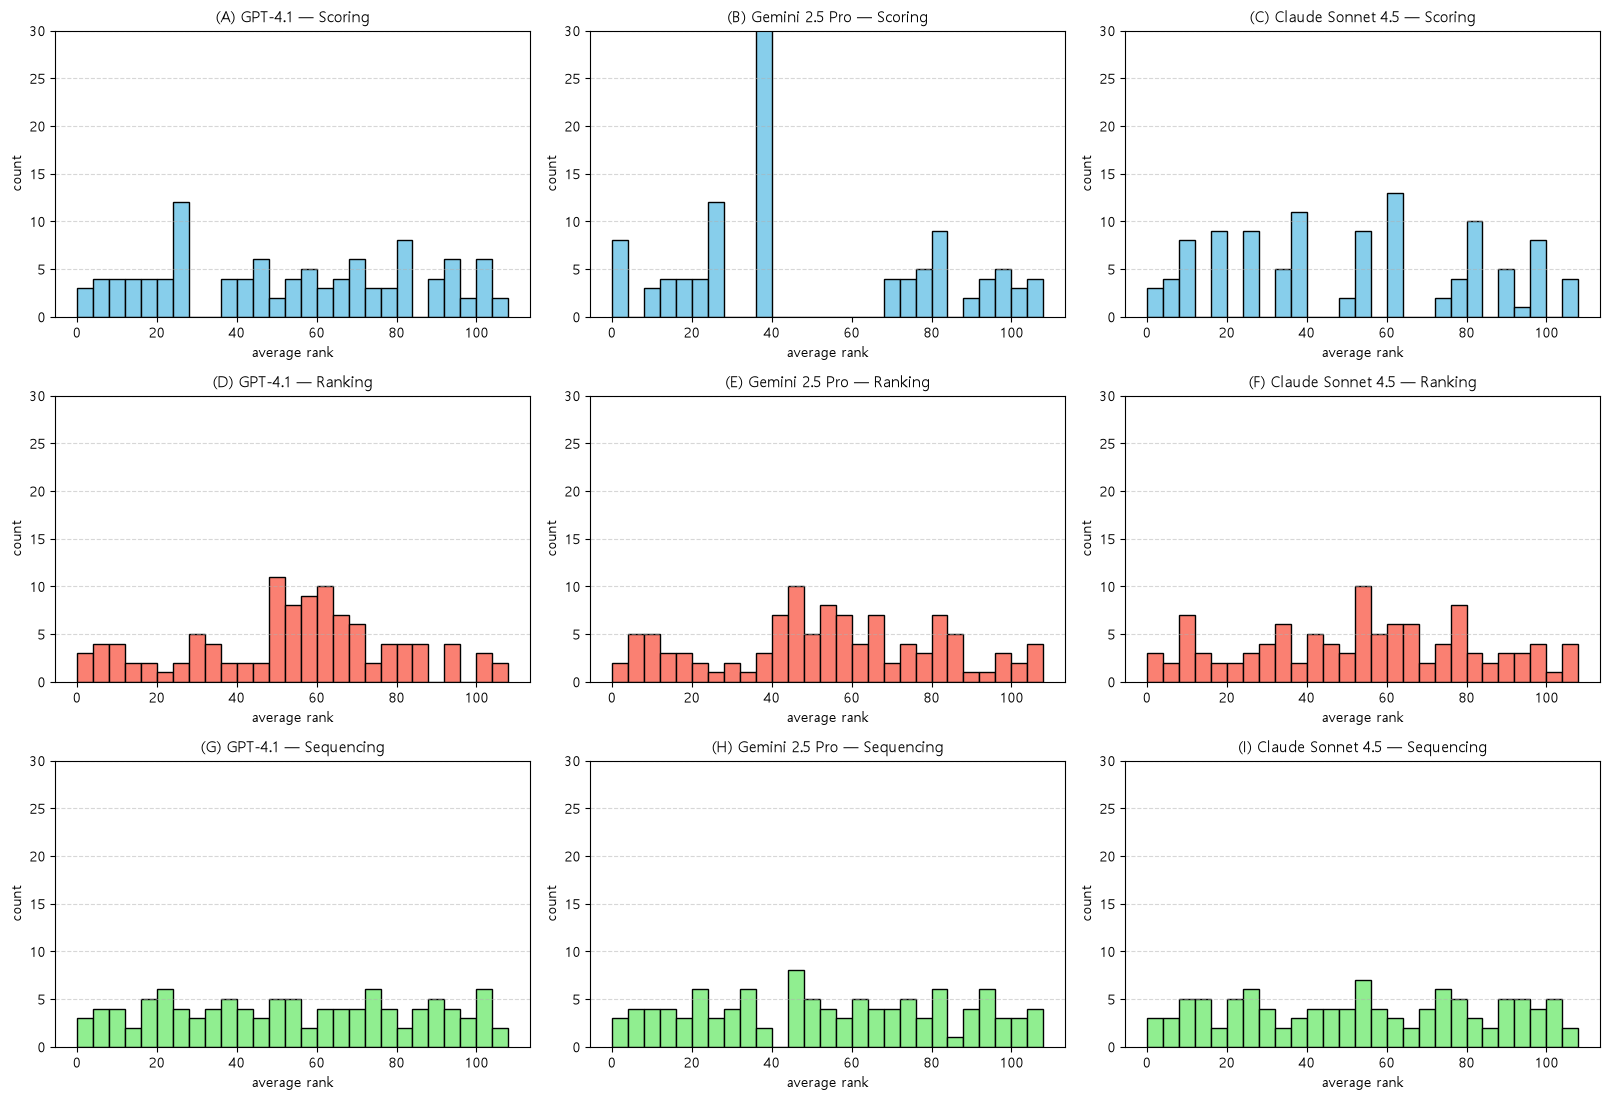

In [11]:
import matplotlib
import matplotlib.pyplot as plt
_avail = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _fam in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if _fam in _avail:
        matplotlib.rcParams['font.family'] = _fam
        break
matplotlib.rcParams['axes.unicode_minus'] = False

HI     = N_POOL + 2
COLORS = {'Scoring': 'skyblue', 'Ranking': 'salmon',
          'Sequencing': 'lightgreen', 'LMprior': 'mediumpurple'}

panels = [(METHNAME[me], mk) for me in ANALYSIS_METHODS for mk in ANALYSIS_MODELS
          if (METHNAME[me], mk) in V]
ncol = len(ANALYSIS_MODELS)
nrow = int(np.ceil(len(panels) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 3.7 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.set_visible(False)
for i, (me, mk) in enumerate(panels):
    ax = axes[i // ncol][i % ncol]
    ax.set_visible(True)
    ax.hist(V[(me, mk)]['v'], bins=np.arange(0, HI, 4),
            edgecolor='black', color=COLORS.get(me, 'gray'))
    ax.set_title(f'({chr(65 + i)}) {MODEL_SHORT[mk]} — {me}', fontsize=11)
    ax.set_xlabel('average rank'); ax.set_ylabel('count')
    ax.set_xticks(np.arange(0, HI, 20)); ax.set_ylim(0, 30)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'Figure2_rank_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

## §6. Table 2 · 3 — 방법 · 모델 간 순위 상관

Spearman ρ 와 Kendall τ, 부트스트랩(B = 5000) 95% 신뢰구간. 재현성을 위해 난수 스트림을
`BOOT_SEED` 로 고정하고 쌍을 도는 순서도 고정한다 (상관계수 자체는 대칭이지만 순서가 바뀌면
CI 끝자리가 ±0.003 흔들린다).

In [12]:
from scipy.stats import spearmanr, kendalltau
RNG = np.random.default_rng(BOOT_SEED)

def stats(a, b, B=B):
    m = pd.merge(a, b, on='feature', suffixes=('_1', '_2'))
    x, y, n = m['v_1'].to_numpy(), m['v_2'].to_numpy(), len(m)
    sp, spp = spearmanr(x, y); kt, ktp = kendalltau(x, y)
    sps, kts = np.empty(B), np.empty(B)
    for i in range(B):
        idx = RNG.integers(0, n, n)
        sps[i] = spearmanr(x[idx], y[idx])[0]
        kts[i] = kendalltau(x[idx], y[idx])[0]
    return dict(n=n, sp=sp, spp=spp, kt=kt, ktp=ktp,
                spci=(np.nanpercentile(sps, 2.5), np.nanpercentile(sps, 97.5)),
                ktci=(np.nanpercentile(kts, 2.5), np.nanpercentile(kts, 97.5)))

def pfmt(p):
    return '<0.001' if p < 1e-3 else f'{p:.3f}'

def row(key, label, s):
    return {key: label[0], 'Compared': label[1], 'n': s['n'],
            'Spearman': f"{s['sp']:.4f}",
            'Sp 95% CI': f"[{s['spci'][0]:.3f}, {s['spci'][1]:.3f}]", 'Sp p': pfmt(s['spp']),
            'Kendall':  f"{s['kt']:.4f}",
            'Kt 95% CI': f"[{s['ktci'][0]:.3f}, {s['ktci'][1]:.3f}]", 'Kt p': pfmt(s['ktp'])}

print('stats helpers ready (B =', B, ')')

stats helpers ready (B = 5000 )


### §6-0. 기준선 — seed 간 일치도

Table 2·3 의 상관값은 그 자체로 해석되지 않는다. 같은 모델·같은 기법으로 seed 만 바꿨을 때의 일치도가 도달 가능한 천장이며, 모델이나 기법을 바꾼 비교는 이 값을 넘을 수 없다.

In [ ]:
# =============================================================================
# 6-0. 기준선 — seed 간 일치도 (도달 가능한 천장)
#   Table 2·3 의 상관값은 그 자체로는 해석되지 않는다. "GPT vs Claude ρ=0.62" 가
#   높은지 낮은지 알려면 비교 대상이 필요하다.
#     바닥 : 무작위 순위 -> ρ ≈ 0
#     천장 : 같은 모델·같은 기법으로 seed 만 바꾼 두 실행 간 상관
#   천장은 "설정을 하나도 안 바꿨을 때도 남는 불일치"이므로, 모델·기법을 바꿨을 때의
#   상관은 이 값을 넘을 수 없다. 아래 값을 Table 2·3 의 참조행으로 함께 보고한다.
# =============================================================================
def seed_pair_stats(method, model_key):
    """같은 (기법, 모델) 안에서 seed 쌍 간 Spearman·Kendall 의 평균과 범위."""
    long = per_seed_long(method, model_key)
    piv  = long.pivot(index='feature', columns='seed', values='rank').dropna()
    sps, kts = [], []
    for s1, s2 in itertools.combinations(piv.columns, 2):
        sps.append(spearmanr(piv[s1], piv[s2])[0])
        kts.append(kendalltau(piv[s1], piv[s2])[0])
    return dict(n_pairs=len(sps),
                sp_mean=float(np.mean(sps)), sp_min=float(np.min(sps)), sp_max=float(np.max(sps)),
                kt_mean=float(np.mean(kts)), kt_min=float(np.min(kts)), kt_max=float(np.max(kts)))

rows_ceil = []
for me in ANALYSIS_METHODS:
    for mk in ANALYSIS_MODELS:
        if (me, mk) not in COMPLETE:
            continue
        s = seed_pair_stats(me, mk)
        rows_ceil.append({'Method': METHNAME[me], 'Model': MODEL_SHORT[mk],
                          'Pairs': s['n_pairs'],
                          'Spearman': round(s['sp_mean'], 4),
                          'Sp range': f"[{s['sp_min']:.3f}, {s['sp_max']:.3f}]",
                          'Kendall': round(s['kt_mean'], 4),
                          'Kt range': f"[{s['kt_min']:.3f}, {s['kt_max']:.3f}]"})
table_ceiling = pd.DataFrame(rows_ceil)
table_ceiling.to_csv(os.path.join(OUT, 'Table2_0_seed_ceiling.csv'),
                     index=False, encoding='utf-8-sig')

CEILING_SP = float(table_ceiling['Spearman'].mean())
CEILING_KT = float(table_ceiling['Kendall'].mean())
print(f'seed 간 일치도 (천장)  Spearman {CEILING_SP:.4f} · Kendall {CEILING_KT:.4f}')
print('Table 2·3 의 상관은 이 값을 상한으로 해석할 것.')
display(table_ceiling)

In [13]:
# ---- Table 2: 같은 방법, 서로 다른 LLM -----------------------------------
rows2 = []
for me in ANALYSIS_METHODS:
    lab = METHNAME[me]
    tmp = [((lab, f'{MODEL_SHORT[a]} vs {MODEL_SHORT[b]}'), stats(V[(lab, a)], V[(lab, b)]))
           for a, b in itertools.combinations(MODEL_ORDER, 2)
           if (lab, a) in V and (lab, b) in V]
    for l, s in sorted(tmp, key=lambda t: -t[1]['sp']):
        rows2.append(row('Method', l, s))

table2 = pd.DataFrame(rows2)
table2.to_csv(os.path.join(OUT, 'Table2_cross_model.csv'), index=False, encoding='utf-8-sig')
table2

,Method,Compared,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,Scoring,GPT-4.1 vs Claude Sonnet 4.5,107,0.9028,"[0.852, 0.935]",<0.001,0.7570,"[0.695, 0.812]",<0.001
1,Scoring,GPT-4.1 vs Gemini 2.5 Pro,107,0.8928,"[0.836, 0.929]",<0.001,0.7604,"[0.697, 0.814]",<0.001
2,Scoring,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8476,"[0.767, 0.903]",<0.001,0.7116,"[0.631, 0.780]",<0.001
3,Ranking,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8578,"[0.781, 0.910]",<0.001,0.6831,"[0.602, 0.755]",<0.001
4,Ranking,GPT-4.1 vs Gemini 2.5 Pro,107,0.7696,"[0.655, 0.854]",<0.001,0.5931,"[0.488, 0.688]",<0.001
5,Ranking,GPT-4.1 vs Claude Sonnet 4.5,107,0.7086,"[0.579, 0.808]",<0.001,0.5301,"[0.419, 0.632]",<0.001
6,Sequencing,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8921,"[0.837, 0.926]",<0.001,0.7136,"[0.652, 0.770]",<0.001
7,Sequencing,GPT-4.1 vs Claude Sonnet 4.5,107,0.8396,"[0.758, 0.893]",<0.001,0.6564,"[0.575, 0.727]",<0.001
8,Sequencing,GPT-4.1 vs Gemini 2.5 Pro,107,0.8246,"[0.738, 0.885]",<0.001,0.6401,"[0.559, 0.715]",<0.001


In [14]:
# ---- Table 3: 같은 모델, 서로 다른 방법 ----------------------------------
METHOD_PAIRS = list(itertools.combinations([METHNAME[m] for m in METHODS], 2))
rows3 = []
for mk in ANALYSIS_MODELS:
    tmp = [((MODEL_SHORT[mk], f'{m1} vs {m2}'), stats(V[(m1, mk)], V[(m2, mk)]))
           for m1, m2 in METHOD_PAIRS if (m1, mk) in V and (m2, mk) in V]
    for l, s in sorted(tmp, key=lambda t: -t[1]['sp']):
        rows3.append(row('Model', l, s))

table3 = pd.DataFrame(rows3)
table3.to_csv(os.path.join(OUT, 'Table3_cross_method.csv'), index=False, encoding='utf-8-sig')
table3

,Model,Compared,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,GPT-4.1,Scoring vs Ranking,107,0.8235,"[0.733, 0.885]",<0.001,0.6500,"[0.561, 0.728]",<0.001
1,GPT-4.1,Ranking vs Sequencing,107,0.6936,"[0.557, 0.797]",<0.001,0.5232,"[0.411, 0.624]",<0.001
2,GPT-4.1,Scoring vs Sequencing,107,0.6314,"[0.476, 0.754]",<0.001,0.4851,"[0.362, 0.596]",<0.001
3,Gemini 2.5 Pro,Ranking vs Sequencing,107,0.7718,"[0.671, 0.842]",<0.001,0.5821,"[0.496, 0.659]",<0.001
4,Gemini 2.5 Pro,Scoring vs Ranking,107,0.7548,"[0.636, 0.844]",<0.001,0.6061,"[0.500, 0.698]",<0.001
5,Gemini 2.5 Pro,Scoring vs Sequencing,107,0.4648,"[0.287, 0.618]",<0.001,0.3504,"[0.218, 0.474]",<0.001
6,Claude Sonnet 4.5,Scoring vs Ranking,107,0.8417,"[0.752, 0.901]",<0.001,0.6813,"[0.595, 0.754]",<0.001
7,Claude Sonnet 4.5,Ranking vs Sequencing,107,0.6453,"[0.485, 0.767]",<0.001,0.4924,"[0.366, 0.605]",<0.001
8,Claude Sonnet 4.5,Scoring vs Sequencing,107,0.5090,"[0.337, 0.659]",<0.001,0.3863,"[0.258, 0.508]",<0.001


### §6-4. 상위권 일치도 — RBO · top-k 겹침

Spearman·Kendall 은 순위 전 구간을 같은 무게로 센다. 실제로 중요한 것은 상위권이므로 상위 가중 지표를 함께 본다.

In [ ]:
# =============================================================================
# 6-4. 상위권 일치도 — RBO 와 top-k 겹침
#   Spearman·Kendall 은 1위↔2위 뒤바뀜과 95위↔103위 뒤바뀜을 같은 무게로 센다.
#   실제로 중요한 것은 상위권이므로, 상위에 가중을 주는 지표를 함께 본다.
#     RBO (Rank-Biased Overlap; Webber et al., ACM TOIS 2010)
#       깊이 d 까지의 겹침을 p^(d-1) 로 가중해 합산. p=0.9 이면 상위 10개가
#       전체 가중의 약 86% 를 차지한다. 0(불일치) ~ 1(완전일치).
#     top-k 겹침
#       상위 k개 집합의 교집합 크기. 해석이 직관적이라 표에 함께 싣는다.
# =============================================================================
RBO_P = 0.9      # 상위 10개가 전체 가중의 약 86% 를 차지하는 설정


def rbo(list1, list2, p=RBO_P, k=None):
    """Rank-Biased Overlap. 두 리스트는 같은 원소 집합의 순열이어야 한다."""
    k = k or max(len(list1), len(list2))
    s1, s2, overlap, total = set(), set(), 0, 0.0
    for d in range(1, k + 1):
        if d <= len(list1): s1.add(list1[d - 1])
        if d <= len(list2): s2.add(list2[d - 1])
        overlap = len(s1 & s2)
        total += (p ** (d - 1)) * (overlap / d)
    return (1 - p) * total


def ordered(vec):
    """v(작을수록 상위) -> 상위부터 나열한 feature 리스트"""
    return vec.sort_values('v')['feature'].tolist()


def topk_overlap(vec1, vec2, k):
    a, b = set(ordered(vec1)[:k]), set(ordered(vec2)[:k])
    return len(a & b)


def rank_agreement(vec1, vec2, p=RBO_P):
    o1, o2 = ordered(vec1), ordered(vec2)
    return {'RBO': round(rbo(o1, o2, p=p), 4),
            'Top10': topk_overlap(vec1, vec2, 10),
            'Top20': topk_overlap(vec1, vec2, 20),
            'Top30': topk_overlap(vec1, vec2, 30)}

In [ ]:
# =============================================================================
# 6-5. Table 2b · 3b — 상위권 일치도 (RBO · top-k)
#   seed 기준선도 같은 지표로 계산해 맨 위에 둔다.
# =============================================================================
rows_top = []

# (a) 기준선: 같은 기법·같은 모델, seed 만 다름
for me in ANALYSIS_METHODS:
    for mk in ANALYSIS_MODELS:
        if (me, mk) not in COMPLETE:
            continue
        long = per_seed_long(me, mk)
        piv  = long.pivot(index='feature', columns='seed', values='rank').dropna()
        accs = []
        for s1, s2 in itertools.combinations(piv.columns, 2):
            v1 = piv[s1].rename('v').reset_index()
            v2 = piv[s2].rename('v').reset_index()
            accs.append(rank_agreement(v1, v2))
        rows_top.append({'Comparison': 'seed (ceiling)',
                         'Pair': f'{METHNAME[me]} / {MODEL_SHORT[mk]}',
                         **{k: round(np.mean([a[k] for a in accs]), 2) for k in accs[0]}})

# (b) 같은 기법, 다른 모델
for me in ANALYSIS_METHODS:
    lab = METHNAME[me]
    for a, b in itertools.combinations(MODEL_ORDER, 2):
        if (lab, a) in V and (lab, b) in V:
            rows_top.append({'Comparison': 'cross-model',
                             'Pair': f'{lab} / {MODEL_SHORT[a]} vs {MODEL_SHORT[b]}',
                             **rank_agreement(V[(lab, a)], V[(lab, b)])})

# (c) 같은 모델, 다른 기법
for mk in ANALYSIS_MODELS:
    for m1, m2 in itertools.combinations([METHNAME[m] for m in ANALYSIS_METHODS], 2):
        if (m1, mk) in V and (m2, mk) in V:
            rows_top.append({'Comparison': 'cross-method',
                             'Pair': f'{MODEL_SHORT[mk]} / {m1} vs {m2}',
                             **rank_agreement(V[(m1, mk)], V[(m2, mk)])})

table_top = pd.DataFrame(rows_top)
table_top.to_csv(os.path.join(OUT, 'Table2b_top_agreement.csv'),
                 index=False, encoding='utf-8-sig')

print(f'RBO (p={RBO_P}) · top-k 겹침 — 비교 유형별 평균')
display(table_top.groupby('Comparison')[['RBO', 'Top10', 'Top20', 'Top30']]
                 .mean().round(3)
                 .reindex(['seed (ceiling)', 'cross-model', 'cross-method']))
display(table_top)

## §7. 분산분해 — 순위 변동의 출처

3 모델 × 3 기법 × 5 seed 완전교차 설계이므로, 변수 순위의 변동을 요인별로 분해할 수 있다. §6 의 쌍별 상관 18개가 답하는 질문을 하나의 수치로 통합한다.

In [ ]:
# =============================================================================
# 7. 분산분해 — 순위 변동의 출처
#   설계가 3 모델 × 3 기법 × 5 seed 완전교차이므로, 변수 순위의 변동을
#   요인별로 분해할 수 있다. Table 2·3 의 쌍별 상관 18개가 답하는 질문
#   ("무엇을 바꾸면 순위가 얼마나 달라지나")을 하나의 수치로 통합한다.
#
#   모형   rank ~ 1 + (1 | model) + (1 | method) + (1 | model:method)
#          변수(feature)를 블록으로 두고 변수마다 적합한 뒤 성분을 평균한다.
#   주의   한 실행의 107개 순위는 1..N 의 순열이라 합이 고정되어 서로 독립이 아니다.
#          절대 순위 대신 [0,1] 정규화 순위를 쓰고, 해석은 상대 비교로 한정한다.
# =============================================================================
LONG_ALL = []
for me in ANALYSIS_METHODS:
    for mk in ANALYSIS_MODELS:
        if (me, mk) not in COMPLETE:
            continue
        d = per_seed_long(me, mk)
        d['method'], d['model'] = METHNAME[me], MODEL_SHORT[mk]
        LONG_ALL.append(d)
LONG_ALL = pd.concat(LONG_ALL, ignore_index=True)

# 실행 단위로 [0,1] 정규화 — 실행마다 순위 범위가 같아지므로 척도 차이를 제거
LONG_ALL['r01'] = LONG_ALL.groupby(['method', 'model', 'seed'])['rank'] \
                          .transform(lambda s: (s.rank(method='average') - 1) / (len(s) - 1))

print(f'관측 {len(LONG_ALL):,}개 = 변수 {LONG_ALL.feature.nunique()} '
      f'× 기법 {LONG_ALL.method.nunique()} × 모델 {LONG_ALL.model.nunique()} '
      f'× seed {LONG_ALL.seed.nunique()}')
display(LONG_ALL.head())

In [ ]:
# =============================================================================
# 7-2. 성분 추정 — 변수별 이원분산분석 제곱합을 평균
#   각 변수의 45개 관측을 model / method / 상호작용 / seed(잔차) 로 분해하고,
#   변수 단위 부트스트랩으로 95% CI 를 붙인다.
# =============================================================================
def decompose_one(g, value='r01'):
    v  = g[value].to_numpy()
    gm = v.mean()
    sst = ((v - gm) ** 2).sum()
    if sst <= 0:
        return None
    ss_model  = sum(len(x) * (x[value].mean() - gm) ** 2 for _, x in g.groupby('model'))
    ss_method = sum(len(x) * (x[value].mean() - gm) ** 2 for _, x in g.groupby('method'))
    ss_inter  = 0.0
    for (a, b), x in g.groupby(['model', 'method']):
        am = g.loc[g.model == a, value].mean()
        bm = g.loc[g.method == b, value].mean()
        ss_inter += len(x) * (x[value].mean() - am - bm + gm) ** 2
    ss_seed = sst - ss_model - ss_method - ss_inter
    return dict(model=ss_model / sst, method=ss_method / sst,
                interaction=ss_inter / sst, seed=max(ss_seed, 0.0) / sst)

per_feature = {f: decompose_one(g) for f, g in LONG_ALL.groupby('feature')}
per_feature = {f: d for f, d in per_feature.items() if d is not None}
VC = pd.DataFrame(per_feature).T
VC.index.name = 'feature'
VC.to_csv(os.path.join(OUT, 'Table5_variance_components_by_feature.csv'), encoding='utf-8-sig')

# 변수 단위 부트스트랩 CI
rng_vc = np.random.default_rng(BOOT_SEED)
feats  = VC.index.to_numpy()
boots  = np.empty((B, 4))
for i in range(B):
    idx = rng_vc.integers(0, len(feats), len(feats))
    boots[i] = VC.loc[feats[idx], ['method', 'model', 'interaction', 'seed']].mean().to_numpy()

table5 = pd.DataFrame({
    'Component': ['Method (rank/score/seq)', 'Model (LLM)', 'Model x Method', 'Seed (run-to-run)'],
    'Share (%)': [round(100 * VC[c].mean(), 1) for c in ['method', 'model', 'interaction', 'seed']],
    '95% CI': [f'[{100*np.percentile(boots[:, j], 2.5):.1f}, '
               f'{100*np.percentile(boots[:, j], 97.5):.1f}]' for j in range(4)],
})
table5.to_csv(os.path.join(OUT, 'Table5_variance_components.csv'), index=False, encoding='utf-8-sig')
display(table5)

In [ ]:
# =============================================================================
# 7-3. 혼합효과모형으로 교차 확인
#   위 제곱합 분해는 변수마다 균형설계가 성립할 때 타당하다. 동일한 질문을
#   임의효과 모형으로 다시 추정해 결론이 바뀌지 않는지 확인한다.
# =============================================================================
try:
    import statsmodels.formula.api as smf

    d = LONG_ALL.copy()
    d['mm'] = d['model'] + ':' + d['method']
    fit = smf.mixedlm('r01 ~ 1', d, groups=d['feature'],
                      re_formula='1',
                      vc_formula={'model': '0 + C(model)',
                                  'method': '0 + C(method)',
                                  'mm': '0 + C(mm)'}).fit(reml=True)
    vc = {k: float(v) for k, v in fit.vcomp_items()} if hasattr(fit, 'vcomp_items') else \
         dict(zip(['model', 'method', 'mm'], np.atleast_1d(fit.vcomp)))
    resid = float(fit.scale)
    tot = sum(vc.values()) + resid
    print('혼합효과모형 분산성분 (feature = 임의효과 블록)')
    for k, v in vc.items():
        print(f'  {k:10} {100*v/tot:5.1f}%')
    print(f'  {"residual":10} {100*resid/tot:5.1f}%')
    print('\n※ 제곱합 분해(위 표)와 순서가 일치하면 결론이 robust 하다.')
except Exception as e:
    print(f'[skip] 혼합효과모형 적합 실패: {type(e).__name__}: {e}')
    print('제곱합 분해 결과만 사용한다.')

## §8. Table 4 · Figure 3 — LMprior

LMprior 는 feature 하나마다 "이 변수가 섬망 예측에 유용한가"를 묻고, 첫 토큰의 `top_logprobs`
에서 Y·N 의 로그확률을 읽어 **`score = log P(Y) − log P(N)`** 으로 점수를 매긴다.

`top_logprobs = 20` 이라 Y나 N이 상위 20개 안에 안 잡힐 수 있는데, 그때 쓰는 `FLOOR = −100.0`
은 **확률 추정치가 아니라 "관측되지 않았다"는 표식**이다. 어느 쪽이 실제로 관측됐는지는
`y_observed` / `n_observed` 에 기록돼 있고, §7-2에서 그 빈도를 확인한다.

In [15]:
# =============================================================================
# 7-1. LMprior 평균 순위 벡터
# =============================================================================
assert HAS_LMPRIOR, f'lmprior/{LMPRIOR_MODEL} 의 seed 5개가 모두 정상이어야 합니다.'

lm_vec = avg_vec('lmprior', LMPRIOR_MODEL)
assert len(lm_vec) == N_POOL and set(lm_vec['feature']) == POOL_SET

_snap = {r.get('model') for s in SEEDS
         for r in read_jsonl(jsonl_path('lmprior', LMPRIOR_MODEL, s))}
assert _snap == {MODELS[LMPRIOR_MODEL]['model']}, f'예상과 다른 스냅샷: {_snap}'
print(f'LMprior 스냅샷 {sorted(_snap)} · seed {SEEDS} · {len(lm_vec)}개 feature')

lm_vec.rename(columns={'v': 'avg_rank'}).to_csv(
    os.path.join(OUT, f'avg_rank_lmprior_{LMPRIOR_MODEL}.csv'), index=False, encoding='utf-8-sig')
lm_vec.head(10)

LMprior 스냅샷 ['gpt-4.1-2025-04-14'] · seed [42, 43, 44, 45, 46] · 107개 feature


,feature,v
0,Use Of Midazolam,1.6
1,Sedation Use,1.6
2,Mechanical Ventilation,3.4
3,Sequential Organ Failure Assessment Score,5.4
4,Alcohol Abuse,6.4
5,Dementia,7.0
6,Vasopressor Use,7.0
7,Systemic Inflammatory Response Syndrome,7.0
8,Age,9.6
9,Sepsis,10.2


In [16]:
# =============================================================================
# 7-2. 진단 — 바닥값 절단 · 응답 분포 · seed 간 일관성
# =============================================================================
lm_long = pd.DataFrame([
    {'seed': s, 'feature': canon(r['feature']), 'answer': r.get('answer'),
     'y_observed': bool(r.get('y_observed', True)),
     'n_observed': bool(r.get('n_observed', True)),
     'score': float(r['score'])}
    for s in SEEDS for r in read_jsonl(jsonl_path('lmprior', LMPRIOR_MODEL, s))
])
n_tot = len(lm_long)
assert n_tot == len(SEEDS) * N_POOL
print(f'총 레코드 {n_tot}  (= {len(SEEDS)} seeds x {N_POOL} features)\n')

print('[응답 분포]')
display(lm_long['answer'].value_counts().rename('n').to_frame()
        .assign(pct=lambda d: (100 * d.n / n_tot).round(1)))

print('[바닥값 절단 — top_logprobs=20 안에서 관측되지 않은 경우]')
trunc = pd.DataFrame({'Y 미관측': [(~lm_long.y_observed).sum()],
                      'N 미관측': [(~lm_long.n_observed).sum()],
                      '둘 다 미관측': [((~lm_long.y_observed) & (~lm_long.n_observed)).sum()]},
                     index=['count'])
trunc.loc['pct'] = (100 * trunc.loc['count'] / n_tot).round(2)
display(trunc)
if trunc.loc['count'].sum() == 0:
    print('  -> 절단 없음. 모든 레코드에서 Y·N 모두 상위 20개 안에 관측됨.\n')

print('[점수 요약]  score = log P(Y) - log P(N)')
display(lm_long['score'].describe().to_frame().T.round(3))

piv = lm_long.pivot(index='feature', columns='seed', values='score')
print('[seed 간 점수 상관 — Spearman]')
display(piv.corr(method='spearman').round(4))
print(f"seed별 점수 표준편차 평균 {piv.std(axis=1, ddof=1).mean():.4f} "
      f"(최대 {piv.std(axis=1, ddof=1).max():.4f})")

총 레코드 535  (= 5 seeds x 107 features)

[응답 분포]


,n,pct
answer,,
Y,402,75.1
N,133,24.9


[바닥값 절단 — top_logprobs=20 안에서 관측되지 않은 경우]


,Y 미관측,N 미관측,둘 다 미관측
count,0.0,0.0,0.0
pct,0.0,0.0,0.0


  -> 절단 없음. 모든 레코드에서 Y·N 모두 상위 20개 안에 관측됨.

[점수 요약]  score = log P(Y) - log P(N)


,count,mean,std,min,25%,50%,75%,max
score,535.0,-18.901,16.07,-38.789,-34.13,-23.645,-3.29,10.125


[seed 간 점수 상관 — Spearman]


seed,42,43,44,45,46
seed,,,,,
42,1.0000,0.9586,0.9198,0.9539,0.9272
43,0.9586,1.0000,0.9118,0.9494,0.9476
44,0.9198,0.9118,1.0000,0.9112,0.9129
45,0.9539,0.9494,0.9112,1.0000,0.9048
46,0.9272,0.9476,0.9129,0.9048,1.0000


seed별 점수 표준편차 평균 1.7814 (최대 18.3902)


In [17]:
# =============================================================================
# 7-3. Table 4 — LMprior vs 다른 방법 (같은 모델)
# =============================================================================
rows4 = []
for me in [METHNAME[m] for m in METHODS]:
    if (me, LMPRIOR_MODEL) not in V:
        continue
    s = stats(V[(me, LMPRIOR_MODEL)], lm_vec)
    rows4.append({'Compared Method': f'{me} vs LMprior', 'n': s['n'],
                  'Spearman': f"{s['sp']:.4f}",
                  'Sp 95% CI': f"[{s['spci'][0]:.3f}, {s['spci'][1]:.3f}]", 'Sp p': pfmt(s['spp']),
                  'Kendall':  f"{s['kt']:.4f}",
                  'Kt 95% CI': f"[{s['ktci'][0]:.3f}, {s['ktci'][1]:.3f}]", 'Kt p': pfmt(s['ktp'])})

table4 = pd.DataFrame(rows4)
table4.to_csv(os.path.join(OUT, 'Table4_lmprior.csv'), index=False, encoding='utf-8-sig')
table4

,Compared Method,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,Scoring vs LMprior,107,0.8430,"[0.757, 0.897]",<0.001,0.6662,"[0.583, 0.736]",<0.001
1,Ranking vs LMprior,107,0.7405,"[0.622, 0.827]",<0.001,0.5518,"[0.454, 0.640]",<0.001
2,Sequencing vs LMprior,107,0.6564,"[0.514, 0.763]",<0.001,0.4773,"[0.367, 0.574]",<0.001


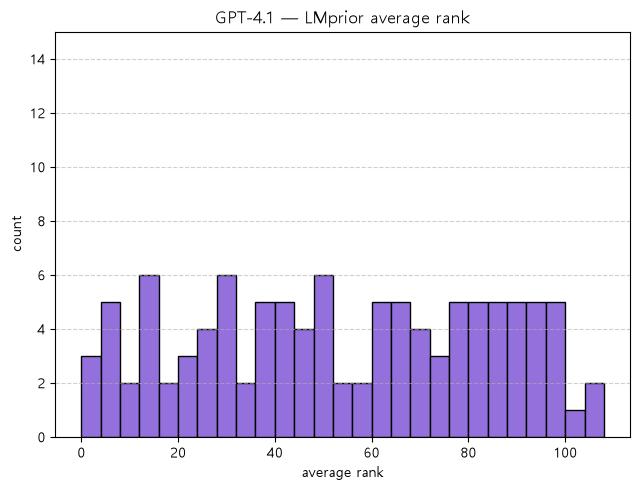

LMprior 상위 15개


,feature,avg_score,std_score,avg_rank
0,Use Of Midazolam,8.882,0.975,1.6
1,Sedation Use,9.001,0.732,1.6
2,Mechanical Ventilation,7.908,0.363,3.4
3,Sequential Organ Failure Assessment Score,6.885,0.605,5.4
4,Alcohol Abuse,6.834,1.124,6.4
5,Dementia,6.482,1.621,7.0
6,Vasopressor Use,6.410,0.154,7.0
7,Systemic Inflammatory Response Syndrome,6.482,0.681,7.0
8,Age,5.621,0.945,9.6
9,Sepsis,5.704,0.592,10.2


In [18]:
# =============================================================================
# 7-4. Figure 3 · LMprior 상하위 feature
# =============================================================================
plt.figure(figsize=(6.5, 5))
plt.hist(lm_vec['v'], bins=np.arange(0, HI, 4), edgecolor='black', color='mediumpurple')
plt.title(f'{MODEL_SHORT[LMPRIOR_MODEL]} — LMprior average rank')
plt.xlabel('average rank'); plt.ylabel('count')
plt.xticks(np.arange(0, HI, 20)); plt.ylim(0, 15)
plt.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'Figure3_lmprior_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

lm_score = (piv.mean(axis=1).rename('avg_score').reset_index()
              .merge(piv.std(axis=1, ddof=1).rename('std_score').reset_index(), on='feature')
              .merge(lm_vec.rename(columns={'v': 'avg_rank'}), on='feature')
              .sort_values('avg_rank'))
lm_score.to_csv(os.path.join(OUT, f'lmprior_{LMPRIOR_MODEL}_scores.csv'),
                index=False, encoding='utf-8-sig')
print('LMprior 상위 15개')
display(lm_score.head(15).round(3).reset_index(drop=True))

## §9. 종합

In [19]:
from IPython.display import display, Markdown

def show(title, df, note=''):
    display(Markdown(f'### {title}' + (f'\n\n{note}' if note else '')))
    display(df)

show('Table 1 — Seed consistency (top-30 std mean, 낮을수록 안정)', table1,
     f'LMprior ({MODEL_SHORT[LMPRIOR_MODEL]}): **{lm_std:.4f}**' if lm_std is not None else '')
show('Table 2 — 같은 방법 · 서로 다른 LLM', table2)
show('Table 3 — 같은 모델 · 서로 다른 방법', table3)
show('Table 4 — LMprior vs 다른 방법', table4)

### Table 1 — Seed consistency (top-30 std mean, 낮을수록 안정)

LMprior (GPT-4.1): **11.7111**

,Scoring,Ranking,Sequencing
Model,,,
GPT-4.1 (OpenAI),5.8492,28.1461,7.6255
Gemini 2.5 Pro (Google),5.5484,22.9632,9.0305
Claude Sonnet 4.5 (Anthropic),2.9847,21.0322,9.1358


### Table 2 — 같은 방법 · 서로 다른 LLM

,Method,Compared,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,Scoring,GPT-4.1 vs Claude Sonnet 4.5,107,0.9028,"[0.852, 0.935]",<0.001,0.7570,"[0.695, 0.812]",<0.001
1,Scoring,GPT-4.1 vs Gemini 2.5 Pro,107,0.8928,"[0.836, 0.929]",<0.001,0.7604,"[0.697, 0.814]",<0.001
2,Scoring,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8476,"[0.767, 0.903]",<0.001,0.7116,"[0.631, 0.780]",<0.001
3,Ranking,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8578,"[0.781, 0.910]",<0.001,0.6831,"[0.602, 0.755]",<0.001
4,Ranking,GPT-4.1 vs Gemini 2.5 Pro,107,0.7696,"[0.655, 0.854]",<0.001,0.5931,"[0.488, 0.688]",<0.001
5,Ranking,GPT-4.1 vs Claude Sonnet 4.5,107,0.7086,"[0.579, 0.808]",<0.001,0.5301,"[0.419, 0.632]",<0.001
6,Sequencing,Gemini 2.5 Pro vs Claude Sonnet 4.5,107,0.8921,"[0.837, 0.926]",<0.001,0.7136,"[0.652, 0.770]",<0.001
7,Sequencing,GPT-4.1 vs Claude Sonnet 4.5,107,0.8396,"[0.758, 0.893]",<0.001,0.6564,"[0.575, 0.727]",<0.001
8,Sequencing,GPT-4.1 vs Gemini 2.5 Pro,107,0.8246,"[0.738, 0.885]",<0.001,0.6401,"[0.559, 0.715]",<0.001


### Table 3 — 같은 모델 · 서로 다른 방법

,Model,Compared,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,GPT-4.1,Scoring vs Ranking,107,0.8235,"[0.733, 0.885]",<0.001,0.6500,"[0.561, 0.728]",<0.001
1,GPT-4.1,Ranking vs Sequencing,107,0.6936,"[0.557, 0.797]",<0.001,0.5232,"[0.411, 0.624]",<0.001
2,GPT-4.1,Scoring vs Sequencing,107,0.6314,"[0.476, 0.754]",<0.001,0.4851,"[0.362, 0.596]",<0.001
3,Gemini 2.5 Pro,Ranking vs Sequencing,107,0.7718,"[0.671, 0.842]",<0.001,0.5821,"[0.496, 0.659]",<0.001
4,Gemini 2.5 Pro,Scoring vs Ranking,107,0.7548,"[0.636, 0.844]",<0.001,0.6061,"[0.500, 0.698]",<0.001
5,Gemini 2.5 Pro,Scoring vs Sequencing,107,0.4648,"[0.287, 0.618]",<0.001,0.3504,"[0.218, 0.474]",<0.001
6,Claude Sonnet 4.5,Scoring vs Ranking,107,0.8417,"[0.752, 0.901]",<0.001,0.6813,"[0.595, 0.754]",<0.001
7,Claude Sonnet 4.5,Ranking vs Sequencing,107,0.6453,"[0.485, 0.767]",<0.001,0.4924,"[0.366, 0.605]",<0.001
8,Claude Sonnet 4.5,Scoring vs Sequencing,107,0.5090,"[0.337, 0.659]",<0.001,0.3863,"[0.258, 0.508]",<0.001


### Table 4 — LMprior vs 다른 방법

,Compared Method,n,Spearman,Sp 95% CI,Sp p,Kendall,Kt 95% CI,Kt p
0,Scoring vs LMprior,107,0.8430,"[0.757, 0.897]",<0.001,0.6662,"[0.583, 0.736]",<0.001
1,Ranking vs LMprior,107,0.7405,"[0.622, 0.827]",<0.001,0.5518,"[0.454, 0.640]",<0.001
2,Sequencing vs LMprior,107,0.6564,"[0.514, 0.763]",<0.001,0.4773,"[0.367, 0.574]",<0.001


In [20]:
# =============================================================================
# 8-1. 방법·모델별 상위 k개 feature
# =============================================================================
K = 30
top_tbl = {f'{me}_{MODEL_SHORT[mk]}': v.sort_values('v').head(K)['feature'].tolist()
           for (me, mk), v in sorted(V.items())}
if HAS_LMPRIOR:
    top_tbl[f'LMprior_{MODEL_SHORT[LMPRIOR_MODEL]}'] = (
        lm_vec.sort_values('v').head(K)['feature'].tolist())

top_df = pd.DataFrame(top_tbl)
top_df.index = range(1, K + 1); top_df.index.name = 'rank'
top_df.to_csv(os.path.join(OUT, f'top{K}_by_method_model.csv'), encoding='utf-8-sig')

union = sorted({f for c in top_df.columns for f in top_df[c]})
inter = sorted(set.intersection(*[set(top_df[c]) for c in top_df.columns]))
print(f'상위 {K}개 합집합 : {len(union)} / {N_POOL}')
print(f'모든 방법·모델의 상위 {K}에 공통으로 든 feature ({len(inter)}개):')
for f in inter:
    print('  -', f)

상위 30개 합집합 : 64 / 107
모든 방법·모델의 상위 30에 공통으로 든 feature (11개):
  - Acute Kidney Injury
  - Age
  - Dementia
  - Glasgow Coma Scale
  - Infection
  - Mechanical Ventilation
  - Sedation Use
  - Sepsis
  - Sequential Organ Failure Assessment Score
  - Use Of Midazolam
  - Vasopressor Use


In [21]:
# =============================================================================
# 8-2. 전체 평균 순위 — 10개 벡터(3방법 x 3모델 + LMprior)의 평균
# =============================================================================
allv = {f'{me.lower()}_{mk}': v.rename(columns={'v': f'{me.lower()}_{mk}'})
        for (me, mk), v in V.items()}
overall = None
for name, v in allv.items():
    overall = v if overall is None else overall.merge(v, on='feature')
if HAS_LMPRIOR:
    overall = overall.merge(lm_vec.rename(columns={'v': f'lmprior_{LMPRIOR_MODEL}'}), on='feature')

cols = [c for c in overall.columns if c != 'feature']
overall['mean_rank'] = overall[cols].mean(axis=1)
overall = overall.sort_values('mean_rank').reset_index(drop=True)
overall.to_csv(os.path.join(OUT, 'overall_ranking.csv'), index=False, encoding='utf-8-sig')

print(f'{len(cols)}개 벡터의 평균 순위 — 상위 20개')
display(overall.head(20).round(2))

10개 벡터의 평균 순위 — 상위 20개


,feature,ranking_claude,ranking_gemini,ranking_gpt,scoring_claude,scoring_gemini,scoring_gpt,sequencing_claude,sequencing_gemini,sequencing_gpt,lmprior_gpt,mean_rank
0,Glasgow Coma Scale,3.6,1.2,2.4,3.0,2.0,3.0,2.0,1.0,1.0,18.2,3.74
1,Sedation Use,8.2,5.0,8.0,1.0,2.0,2.0,3.2,4.2,3.0,1.6,3.82
2,Sequential Organ Failure Assessment Score,4.2,5.8,3.8,4.0,9.0,7.0,6.0,3.0,5.0,5.4,5.32
3,Dementia,8.6,3.2,1.8,2.0,2.0,1.0,13.2,12.0,6.0,7.0,5.68
4,Mechanical Ventilation,9.0,10.8,7.8,5.0,2.0,5.0,5.0,4.8,4.0,3.4,5.68
5,Age,14.6,8.8,11.0,19.0,2.0,8.0,1.0,2.0,2.0,9.6,7.80
6,Sepsis,11.0,11.4,9.2,5.0,1.0,6.0,9.0,8.6,7.0,10.2,7.84
7,Acute Physiology and Chronic Health Evaluation...,4.0,4.4,4.8,8.0,25.0,10.0,5.4,6.4,16.0,12.8,9.68
8,Use Of Midazolam,14.4,7.2,9.4,7.0,2.0,4.0,21.8,11.6,18.8,1.6,9.78
9,Vasopressor Use,11.4,8.8,7.8,16.0,17.0,12.0,9.2,8.4,10.0,7.0,10.76


In [22]:
# =============================================================================
# 8-3. 토큰 사용량 — 모델별 조건 차이를 그대로 드러낸다
# =============================================================================
_tok = os.path.join(AGG_DIR, 'token_usage.csv')
if os.path.exists(_tok):
    tok = pd.read_csv(_tok, encoding='utf-8-sig')
    tok.columns = [c.strip().lstrip('﻿') for c in tok.columns]
    display(tok)
    if 'thinking_tokens' in tok.columns:
        th = tok.groupby('model')['thinking_tokens'].sum()
        print('\n모델별 thinking 토큰 합계:')
        for m, v in th.items():
            print(f'  {m:34} {int(v):>8,}')
        print('\nGemini 2.5 Pro 는 thinking 을 비활성화할 수 없어 thinkingBudget 을 최소값(128)로')
        print('설정했으나 이는 상한이 아닌 목표치이며, 실제 사용량은 위와 같다. GPT-4.1 과')
        print('Claude Sonnet 4.5 는 thinking 을 사용하지 않았다(0).')
    tok.to_csv(os.path.join(OUT, 'token_usage_summary.csv'), index=False, encoding='utf-8-sig')
else:
    print('token_usage.csv 없음 — 건너뜀')

print('\n저장된 산출물:')
for f in sorted(os.listdir(OUT)):
    print('  ', f)

,model,method,n_calls,prompt_tokens,completion_tokens,thinking_tokens,mean_thinking_per_call
0,claude-sonnet-4-5-20250929,rank,535,214963,180295,0,0.000000
1,claude-sonnet-4-5-20250929,score,535,115780,55951,0,0.000000
2,claude-sonnet-4-5-20250929,seq,535,607871,39306,0,0.000000
3,gemini-2.5-pro,rank,535,158467,150656,36273,67.800000
4,gemini-2.5-pro,score,535,104610,41970,47222,88.265421
5,gemini-2.5-pro,seq,535,411955,35008,82526,154.254206
6,gpt-4.1-2025-04-14,lmprior,535,63720,22958,0,0.000000
7,gpt-4.1-2025-04-14,rank,535,173768,122729,0,0.000000
8,gpt-4.1-2025-04-14,score,535,99565,29218,0,0.000000
9,gpt-4.1-2025-04-14,seq,535,440310,28604,0,0.000000



모델별 thinking 토큰 합계:
  claude-sonnet-4-5-20250929                0
  gemini-2.5-pro                      166,021
  gpt-4.1-2025-04-14                        0

Gemini 2.5 Pro 는 thinking 을 비활성화할 수 없어 thinkingBudget 을 최소값(128)로
설정했으나 이는 상한이 아닌 목표치이며, 실제 사용량은 위와 같다. GPT-4.1 과
Claude Sonnet 4.5 는 thinking 을 사용하지 않았다(0).

저장된 산출물:
   Figure2_rank_distribution.png
   Figure3_lmprior_distribution.png
   Table1_seed_consistency.csv
   Table2_cross_model.csv
   Table3_cross_method.csv
   Table4_lmprior.csv
   avg_rank_lmprior_gpt.csv
   inventory.csv
   lmprior_gpt_scores.csv
   overall_ranking.csv
   pool_audit.csv
   token_usage_summary.csv
   top30_by_method_model.csv


---

### Downstream 평가 (MIMIC-IV)

각 selection 방법이 고른 상위 k개 변수로 실제 섬망 예측 모델을 학습해 AUC를 비교하는 부분은
**이 노트북에 포함하지 않았다.** 107개 pool 에 맞춰 MIMIC-IV 추출 SQL 과 컬럼 매핑을 다시
만든 뒤에야 실행할 수 있기 때문이다. 103개 pool 기준의 이전 구현은
`LLM_FeatureSelection_Pipeline_OLD.ipynb` §9 에 남아 있다.

필요한 것은 두 가지다.

1. 107개 pool 전체를 담은 추출 결과 (`mimic_iv_dataset_107.csv`)
2. `FEATURE_MAPPING` — pool 표기 107개에서 MIMIC 컬럼으로의 매핑 (의도적 제외는 `None`)

이 노트북의 `overall_ranking.csv` 와 `top30_by_method_model.csv` 가 그대로 입력이 된다.